In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import optuna

In [2]:
df = pd.read_csv(r"C:\Users\swapn\Downloads\dataset\data.csv")

In [3]:
df

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9539,NaN,NaN,"['Mathematical modelling', 'Machine Learning',...",['Sanghvi College of Engineering'],['B.Tech'],['2019'],['N/A'],['N/A'],['N/A'],['BPM Foundation'],...,NaN,NaN,NaN,Data Engineer,Bachelor of Science (BSc),5 to 8 years,NaN,Data Platform Design\nData Pipeline Developmen...,Azure\nBig Data\nData Analytics\nETL Tools\nPo...,0.683333
9540,NaN,Expertise EDA modeler. I like to learn what my...,"['Data Analysis', 'Business Analysis', 'Machin...","['KVoCT, Pune', 'KVoCT, Pune']","['B.CA', 'M.CA']","['2018', '2020']","[None, None]","[None, None]","[None, None]",['Passionate Solution'],...,NaN,NaN,NaN,Executive/ Sr. Executive -IT,Bachelor of Science (BSc) in Computer Science ...,3 to 5 years,Age at most 40 years,Hardware & Software Installation\nSystem Monit...,NaN,0.650000
9541,NaN,Looking for roles related to application devel...,"['Business Analyst', 'Data Analytics', 'Data C...",['PGG College Mysore'],['B.BA'],['2019'],['N/A'],['N/A'],['N/A'],['ZigSAW'],...,NaN,NaN,NaN,Executive - VAT,BBA in Accounting and Finance,1 to 3 years,NaN,Mushak Forms Maintenance\nVAT Software & MS Of...,VAT and Tax,0.650000
9542,NaN,NaN,"['Machine Learning', 'Natural Language Process...","['Rajiv Gandhi Me

In [4]:
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [5]:
df.shape

(9544, 35)

In [6]:
df.columns

Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names',
       'extra_curricular_organization_links', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'online_links', 'issue_dates', 'expiry_dates', '﻿job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   address                              784 non-null    object 
 1   career_objective                     4740 non-null   object 
 2   skills                               9488 non-null   object 
 3   educational_institution_name         9460 non-null   object 
 4   degree_names                         9460 non-null   object 
 5   passing_years                        9460 non-null   object 
 6   educational_results                  9460 non-null   object 
 7   result_types                         9460 non-null   object 
 8   major_field_of_studies               9460 non-null   object 
 9   professional_company_names           9460 non-null   object 
 10  company_urls                         9460 non-null   object 
 11  start_dates                   

In [8]:
df.describe()

,matched_score
count,9544.000000
mean,0.660831
std,0.167040
min,0.000000
25%,0.583333
50%,0.683333
75%,0.793333
max,0.970000


In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

address                                8760
career_objective                       4804
skills                                   56
educational_institution_name             84
degree_names                             84
passing_years                            84
educational_results                      84
result_types                             84
major_field_of_studies                   84
professional_company_names               84
company_urls                             84
start_dates                              84
end_dates                                84
related_skils_in_job                     84
positions                                84
locations                                84
responsibilities                          0
extra_curricular_activity_types        6118
extra_curricular_organization_names    6118
extra_curricular_organization_links    6118
role_positions                         6118
languages                              8844
proficiency_levels              

In [11]:
(df.isnull().sum()/len(df))*100

address                                91.785415
career_objective                       50.335289
skills                                  0.586756
educational_institution_name            0.880134
degree_names                            0.880134
passing_years                           0.880134
educational_results                     0.880134
result_types                            0.880134
major_field_of_studies                  0.880134
professional_company_names              0.880134
company_urls                            0.880134
start_dates                             0.880134
end_dates                               0.880134
related_skils_in_job                    0.880134
positions                               0.880134
locations                               0.880134
responsibilities                        0.000000
extra_curricular_activity_types        64.103101
extra_curricular_organization_names    64.103101
extra_curricular_organization_links    64.103101
role_positions      

In [12]:
df.fillna("Unknown", inplace=True)

In [13]:
df.shape

(9544, 35)

In [14]:
df.columns

Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names',
       'extra_curricular_organization_links', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'online_links', 'issue_dates', 'expiry_dates', '﻿job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')

In [15]:
df.isnull().sum().head()

address                         0
career_objective                0
skills                          0
educational_institution_name    0
degree_names                    0
dtype: int64

In [16]:
df.rename(columns={'﻿job_position_name':'job_position_name'}, inplace=True)

In [17]:
df.columns

Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names',
       'extra_curricular_organization_links', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'online_links', 'issue_dates', 'expiry_dates', 'job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')

In [18]:
df.drop(columns=[
    'company_urls',
    'online_links',
    'extra_curricular_organization_links'
], inplace=True)

In [19]:
df.select_dtypes(include=['int64','float64']).columns

Index(['matched_score'], dtype='object')

In [20]:
df.describe()

,matched_score
count,9544.000000
mean,0.660831
std,0.167040
min,0.000000
25%,0.583333
50%,0.683333
75%,0.793333
max,0.970000


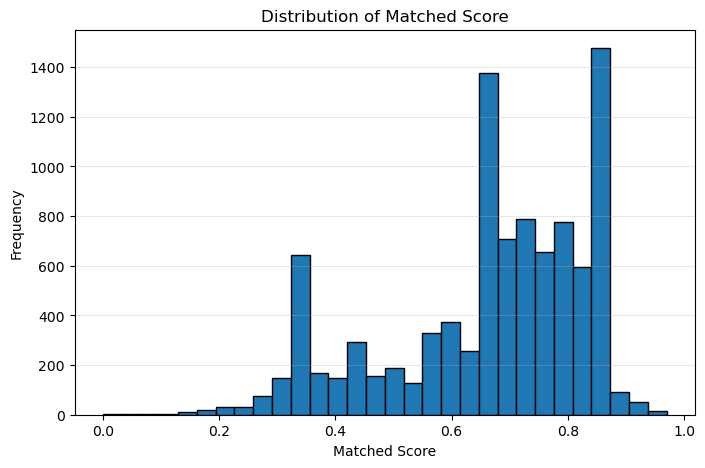

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['matched_score'],
         bins=30,
         edgecolor='black')

plt.title("Distribution of Matched Score")
plt.xlabel("Matched Score")
plt.ylabel("Frequency")

plt.grid(axis='y', alpha=0.3)

plt.show()

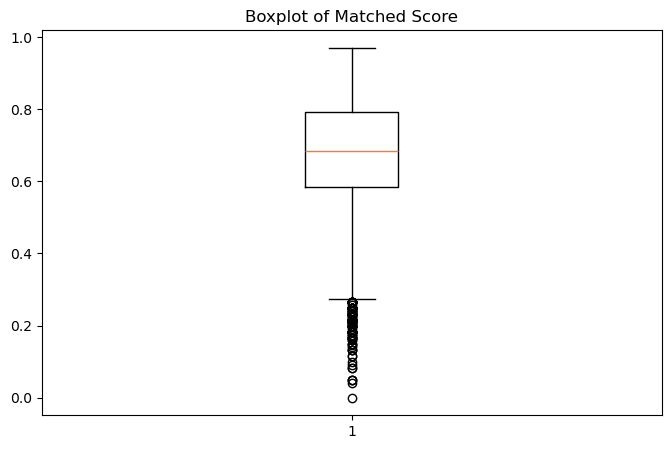

In [22]:
plt.figure(figsize=(8,5))
plt.boxplot(df['matched_score'])
plt.title("Boxplot of Matched Score")
plt.show()

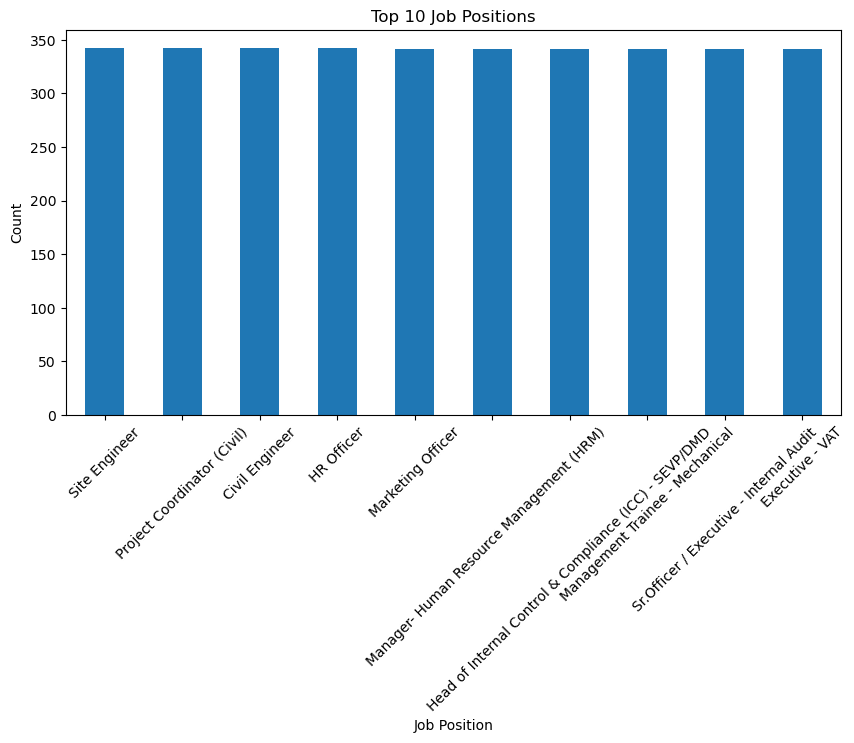

In [23]:
plt.figure(figsize=(10,5))

df['job_position_name'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Job Positions")
plt.xlabel("Job Position")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

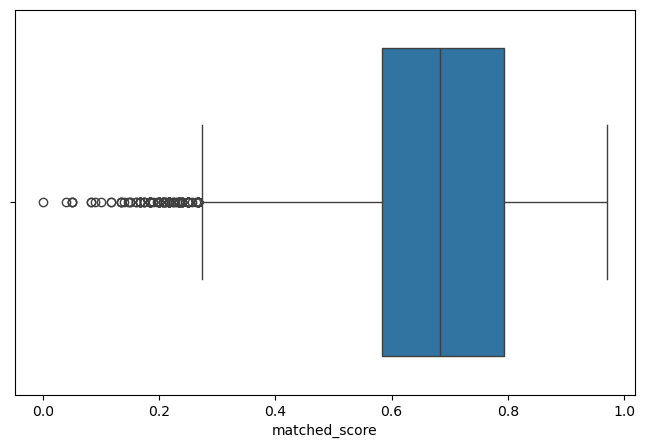

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['matched_score'])
plt.show()

In [25]:
X = df.drop('matched_score', axis=1)

In [26]:
y = df['matched_score']

In [27]:
print(X.shape)
print(y.shape)

(9544, 31)
(9544,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7635, 31)
X_test : (1909, 31)
y_train: (7635,)
y_test : (1909,)


In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [31]:
print("Training Set  :", X_train.shape)
print("Validation Set:", X_val.shape)
print("Testing Set   :", X_test.shape)

Training Set  : (6108, 31)
Validation Set: (1527, 31)
Testing Set   : (1909, 31)


In [32]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

cat_cols = X_train.select_dtypes(include=['object']).columns

In [33]:
print("Numerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

Numerical Columns
Index([], dtype='object')

Categorical Columns
Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'start_dates',
       'end_dates', 'related_skils_in_job', 'positions', 'locations',
       'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'issue_dates', 'expiry_dates', 'job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required'],
      dtype='object')


In [34]:
# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("Encoding", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [35]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [36]:
# Baseline ANN Model (Regression)
baseline_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])

C:\Users\swapn\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [38]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │         112,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 114,497 (447.25 KB)

 Trainable params: 114,497 (447.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
print(X_train_processed.shape)
print(y_train.shape)

print(X_val_processed.shape)
print(y_val.shape)

(6108, 3509)
(6108,)
(1527, 3509)
(1527,)


In [40]:
from tensorflow.keras.callbacks import EarlyStopping

# Early Stopping
early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
history = baseline_model.fit(
    X_train_processed,
    y_train,
    epochs=50,
    validation_data=(X_val_processed, y_val),
    batch_size=256,
    callbacks=[early],
    verbose=2
)

Epoch 1/50
24/24 - 7s - 307ms/step - loss: 0.1583 - mae: 0.3173 - val_loss: 0.0269 - val_mae: 0.1234
Epoch 2/50
24/24 - 4s - 157ms/step - loss: 0.0196 - mae: 0.1132 - val_loss: 0.0194 - val_mae: 0.1071
Epoch 3/50
24/24 - 3s - 110ms/step - loss: 0.0144 - mae: 0.0934 - val_loss: 0.0167 - val_mae: 0.1001
Epoch 4/50
24/24 - 2s - 102ms/step - loss: 0.0135 - mae: 0.0895 - val_loss: 0.0163 - val_mae: 0.0989
Epoch 5/50
24/24 - 2s - 64ms/step - loss: 0.0129 - mae: 0.0877 - val_loss: 0.0161 - val_mae: 0.0985
Epoch 6/50
24/24 - 3s - 107ms/step - loss: 0.0123 - mae: 0.0858 - val_loss: 0.0155 - val_mae: 0.0957
Epoch 7/50
24/24 - 3s - 110ms/step - loss: 0.0117 - mae: 0.0833 - val_loss: 0.0146 - val_mae: 0.0933
Epoch 8/50
24/24 - 1s - 53ms/step - loss: 0.0108 - mae: 0.0799 - val_loss: 0.0137 - val_mae: 0.0898
Epoch 9/50
24/24 - 1s - 60ms/step - loss: 0.0098 - mae: 0.0759 - val_loss: 0.0130 - val_mae: 0.0872
Epoch 10/50
24/24 - 3s - 104ms/step - loss: 0.0089 - mae: 0.0724 - val_loss: 0.0125 - val_mae:

In [41]:
y_pred = baseline_model.predict(X_test_processed)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.07827105335454441
Mean Squared Error (MSE): 0.010632699191129956
Root Mean Squared Error (RMSE): 0.10311498043994362
R² Score: 0.6155011383389655


In [43]:
!pip install optuna

In [44]:
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [45]:
def objective(trial):

    # Hyperparameters
    n1 = trial.suggest_int('neurons_layer1', 32, 128)
    n2 = trial.suggest_int('neurons_layer2', 16, 64)

    dropout_rate = trial.suggest_float(
        'dropout_rate',
        0.1,
        0.5
    )

    learning_rate = trial.suggest_float(
        'learning_rate',
        1e-5,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        'batch_size',
        [32, 64, 128, 256]
    )


    # ANN Model
    model = Sequential([
        Input(shape=(X_train_processed.shape[1],)),

        Dense(n1, activation='relu'),

        Dropout(dropout_rate),

        Dense(n2, activation='relu'),

        Dense(1, activation='linear')
    ])


    # Compile
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )


    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )


    # Training
    model.fit(
        X_train_processed,
        y_train,
        validation_data=(X_val_processed, y_val),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )


    # Validation prediction
    y_val_pred = model.predict(
        X_val_processed,
        verbose=0
    )


    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            y_val_pred
        )
    )


    return rmse

In [47]:
study = optuna.create_study(
    direction='minimize'
)

study.optimize(
    objective,
    n_trials=20
)

[I 2026-07-10 00:09:34,073] A new study created in memory with name: no-name-89450147-2e21-494e-95ad-9b062d8b43c9
[I 2026-07-10 00:10:40,598] Trial 0 finished with value: 0.1329390862022561 and parameters: {'neurons_layer1': 56, 'neurons_layer2': 39, 'dropout_rate': 0.30594732797558677, 'learning_rate': 5.650059659207744e-05, 'batch_size': 32}. Best is trial 0 with value: 0.1329390862022561.
[I 2026-07-10 00:12:19,616] Trial 1 finished with value: 0.10448906607708375 and parameters: {'neurons_layer1': 112, 'neurons_layer2': 62, 'dropout_rate': 0.2265085353150508, 'learning_rate': 0.0042544673185097815, 'batch_size': 32}. Best is trial 1 with value: 0.10448906607708375.
[I 2026-07-10 00:13:11,674] Trial 2 finished with value: 0.10342591939948696 and parameters: {'neurons_layer1': 52, 'neurons_layer2': 36, 'dropout_rate': 0.12655553232480996, 'learning_rate': 0.0025606939527309173, 'batch_size': 64}. Best is trial 2 with value: 0.10342591939948696.
[I 2026-07-10 00:14:26,366] Trial 3 fin

In [48]:
study.best_params

{'neurons_layer1': 102,
 'neurons_layer2': 47,
 'dropout_rate': 0.14827868500077274,
 'learning_rate': 0.0009650889107407299,
 'batch_size': 32}

In [49]:
study.best_value

0.10183666158241145

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# Tuned ANN Model
tuned_model = Sequential([
    
    Input(shape=(X_train_processed.shape[1],)),
    
    Dense(100, activation='relu'),
    
    Dropout(0.173),
    
    Dense(49, activation='relu'),
    
    Dense(1, activation='linear')
])


# Compile model
tuned_model.compile(
    optimizer=Adam(learning_rate=0.000724),
    loss='mse',
    metrics=['mae']
)


tuned_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                     │ (None, 100)                 │         351,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 49)                  │           4,949 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 1)                   │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 355,999 (1.36 MB)

 Trainable params: 355,999 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [52]:
history_tuned = tuned_model.fit(
    X_train_processed,
    y_train,
    epochs=100,
    validation_data=(X_val_processed, y_val),
    batch_size=128,
    callbacks=[early],
    verbose=2
)

Epoch 1/100
48/48 - 9s - 178ms/step - loss: 0.0520 - mae: 0.1735 - val_loss: 0.0203 - val_mae: 0.1143
Epoch 2/100
48/48 - 2s - 37ms/step - loss: 0.0191 - mae: 0.1099 - val_loss: 0.0173 - val_mae: 0.1035
Epoch 3/100
48/48 - 3s - 52ms/step - loss: 0.0162 - mae: 0.1005 - val_loss: 0.0161 - val_mae: 0.1011
Epoch 4/100
48/48 - 2s - 32ms/step - loss: 0.0137 - mae: 0.0920 - val_loss: 0.0149 - val_mae: 0.0955
Epoch 5/100
48/48 - 2s - 33ms/step - loss: 0.0123 - mae: 0.0868 - val_loss: 0.0144 - val_mae: 0.0942
Epoch 6/100
48/48 - 2s - 35ms/step - loss: 0.0111 - mae: 0.0827 - val_loss: 0.0135 - val_mae: 0.0908
Epoch 7/100
48/48 - 2s - 35ms/step - loss: 0.0099 - mae: 0.0781 - val_loss: 0.0133 - val_mae: 0.0903
Epoch 8/100
48/48 - 2s - 34ms/step - loss: 0.0090 - mae: 0.0746 - val_loss: 0.0135 - val_mae: 0.0917
Epoch 9/100
48/48 - 2s - 33ms/step - loss: 0.0083 - mae: 0.0713 - val_loss: 0.0134 - val_mae: 0.0921
Epoch 10/100
48/48 - 2s - 32ms/step - loss: 0.0079 - mae: 0.0701 - val_loss: 0.0128 - val_

In [53]:
y_pred_tuned = tuned_model.predict(X_test_processed)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae = mean_absolute_error(y_test, y_pred_tuned)

mse = mean_squared_error(y_test, y_pred_tuned)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_tuned)


print("Tuned ANN Results")
print("----------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Tuned ANN Results
----------------------
MAE : 0.07930864333362904
MSE : 0.010746510406330597
RMSE: 0.1036653770857493
R2 Score: 0.6113855058074432


In [55]:
baseline_pred = baseline_model.predict(X_test_processed)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [56]:
comparison = pd.DataFrame({
    "Model": ["Baseline ANN", "Tuned ANN"],
    "MAE": [baseline_mae, mae],
    "RMSE": [baseline_rmse, rmse],
    "R2 Score": [baseline_r2, r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Baseline ANN,0.078271,0.103115,0.615501
1,Tuned ANN,0.079309,0.103665,0.611386


In [57]:
# Select the best performing model
final_model = baseline_model

In [69]:
final_model.save("ann_model.keras")

In [70]:
import pickle
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)